# UNSW-NB15 : CNN Binary Intrusion Detection
**Pipeline:** Preprocessing -> PyTorch DataLoaders -> CNN -> 5-Fold CV -> Evaluation

**Task:** Binary classification — `0 = BENIGN` vs `1 = ATTACK`

## 1. Configuration

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
DATA_PATH        = '/content/drive/MyDrive/Tez_kodu/UNSW-NB15'
MISSING_STRATEGY = 'mean'
SCALING          = 'quantile'
SPLIT            = 'stratified'
OVERSAMPLING     = 'smote'
TASK             = 'binary'
ENCODING         = 'onehot'
LOSS_CHOICE      = 'focal'
TEST_SIZE        = 0.2
RANDOM_STATE     = 42
CLASS_NAMES      = ['BENIGN', 'ATTACK']

# CNN Hyperparameters
BATCH_SIZE   = 256
EPOCHS       = 100
LR           = 1e-3
N_FOLDS      = 5
PATIENCE     = 7
THRESHOLD    = 0.5

# CNN blocks: list of (out_channels, kernel_size)
# Each block: Conv1d → BN → ReLU → Dropout → MaxPool1d(2)
CNN_BLOCKS = [
    (64,  3),   # Block 1
    (128, 3),   # Block 2
    (256, 3),   # Block 3
]
CNN_DROPOUT  = 0.3
POOL_SIZE    = 2   # MaxPool kernel size (set to 1 to disable)

# Classifier head
FC_LAYERS    = [256, 128]   # hidden FC dims after GlobalAvgPool
FC_DROPOUT   = 0.4

print(' Configuration loaded')
print(f'  Task: {TASK} | Scaling: {SCALING} | Oversampling: {OVERSAMPLING}')
print(f'  Loss: {LOSS_CHOICE} | Threshold: {THRESHOLD}')
print(f'  CNN blocks: {CNN_BLOCKS}')
print(f'  Batch: {BATCH_SIZE} | Epochs: {EPOCHS} | Folds: {N_FOLDS} | Patience: {PATIENCE}')

 Configuration loaded
  Task: binary | Scaling: quantile | Oversampling: smote
  Loss: focal | Threshold: 0.5
  CNN blocks: [(64, 3), (128, 3), (256, 3)]
  Batch: 256 | Epochs: 100 | Folds: 5 | Patience: 7


## 2. Imports

In [4]:
import os, glob, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, QuantileTransformer,
    LabelEncoder, OneHotEncoder, TargetEncoder
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score,
    precision_recall_curve, roc_curve, auc,
    average_precision_score
)

from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN, RandomOverSampler
from imblearn.combine import SMOTETomek

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Imports OK  |  Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')

 Imports OK  |  Device: cuda
  GPU: NVIDIA L4


## 3. Data Loading

In [5]:
if os.path.isdir(DATA_PATH):
    csv_files = glob.glob(os.path.join(DATA_PATH, '*.csv'))
    print(f'{len(csv_files)} CSV files found:')
    for f in csv_files:
        print(f'   {os.path.basename(f)}')
    df = pd.concat([pd.read_csv(f, low_memory=False) for f in csv_files], ignore_index=True)
else:
    df = pd.read_csv(DATA_PATH, low_memory=False)

df.columns = df.columns.str.strip().str.lower()
print(f'\nShape: {df.shape}')
print(f'Columns sample: {list(df.columns[:8])}')

2 CSV files found:
   UNSW_NB15_training-set.csv
   UNSW_NB15_testing-set.csv

Shape: (257673, 45)
Columns sample: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes']


## 4. Cleaning & Encoding

In [6]:
# 4.1 Infinite -> NaN
inf_count = np.isinf(df.select_dtypes(include=np.number)).sum().sum()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f'{inf_count:,} infinite values replaced by NaN')

# 4.2 Missing values
if MISSING_STRATEGY == 'drop':
    df.dropna(inplace=True)
else:
    num_cols = df.select_dtypes(include=np.number).columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
print(f'Missing after: {df.isnull().sum().sum()}')

# 4.3 Binary target
df['label_encoded'] = df['label'].astype(int)
print('Binary target distribution:')
vc = df['label_encoded'].value_counts().sort_index()
for idx, count in vc.items():
    name = CLASS_NAMES[idx] if idx < len(CLASS_NAMES) else idx
    print(f'  {idx} ({name}): {count:,}  ({count/len(df)*100:.1f}%)')

# 4.4 Categorical OneHot
EXCLUDE  = ['label', 'attack_cat', 'label_encoded']
cat_cols = [c for c in df.select_dtypes(include='object').columns if c not in EXCLUDE]
if cat_cols and ENCODING == 'onehot':
    df = pd.get_dummies(df, columns=cat_cols, drop_first=False)
    print(f'OneHot applied on: {cat_cols}')

# 4.5 Feature matrix
FEATURE_COLS = [c for c in df.select_dtypes(include=np.number).columns if c not in EXCLUDE]
X = df[FEATURE_COLS].copy().astype(np.float32)
y = df['label_encoded'].values.astype(np.int64)

N_FEATURES = X.shape[1]
N_CLASSES  = 2
print(f'\nFeatures: {N_FEATURES} | Samples: {X.shape[0]:,} | Classes: {N_CLASSES}')

0 infinite values replaced by NaN
Missing after: 0
Binary target distribution:
  0 (BENIGN): 93,000  (36.1%)
  1 (ATTACK): 164,673  (63.9%)
OneHot applied on: ['proto', 'service', 'state']

Features: 40 | Samples: 257,673 | Classes: 2


## 5. Train / Validation / Test Split

In [7]:
stratify_param = y if SPLIT == 'stratified' else None
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=stratify_param
)
stratify_temp = y_temp if SPLIT == 'stratified' else None
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.333, random_state=RANDOM_STATE, stratify=stratify_temp
)
print(f'Split ({SPLIT})')
print(f'  Train      : {X_train.shape[0]:,} (70%)')
print(f'  Validation : {X_val.shape[0]:,} (10%)')
print(f'  Test       : {X_test.shape[0]:,} (20%)')

Split (stratified)
  Train      : 180,371 (70%)
  Validation : 25,742 (10%)
  Test       : 51,560 (20%)


## 6. Scaling

In [8]:
if SCALING is None:
    X_train_scaled = X_train.values.astype(np.float32)
    X_val_scaled   = X_val.values.astype(np.float32)
    X_test_scaled  = X_test.values.astype(np.float32)
    print('No scaling applied')
else:
    scalers = {
        'standard': StandardScaler(),
        'minmax'  : MinMaxScaler(),
        'quantile': QuantileTransformer(output_distribution='normal', random_state=RANDOM_STATE)
    }
    scaler = scalers[SCALING]
    X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
    X_val_scaled   = scaler.transform(X_val).astype(np.float32)
    X_test_scaled  = scaler.transform(X_test).astype(np.float32)
    print(f' Scaling [{SCALING}] applied — fit on train only')

 Scaling [quantile] applied — fit on train only


## 7. Oversampling (train only)

In [9]:
y_train_arr = y_train if isinstance(y_train, np.ndarray) else np.array(y_train)
print(f'Before: {dict(zip(*np.unique(y_train_arr, return_counts=True)))}')

if OVERSAMPLING is None:
    X_train_res, y_train_res = X_train_scaled, y_train_arr
    print('No oversampling')
else:
    oversamplers = {
        'smote'           : SMOTE(random_state=RANDOM_STATE),
        'borderline_smote': BorderlineSMOTE(random_state=RANDOM_STATE),
        'adasyn'          : ADASYN(random_state=RANDOM_STATE),
        'smote_tomek'     : SMOTETomek(random_state=RANDOM_STATE),
        'random'          : RandomOverSampler(random_state=RANDOM_STATE)
    }
    sampler = oversamplers[OVERSAMPLING]
    X_train_res, y_train_res = sampler.fit_resample(X_train_scaled, y_train_arr)
    X_train_res = X_train_res.astype(np.float32)
    y_train_res = y_train_res.astype(np.int64)
    print(f' {OVERSAMPLING} applied')

print(f'After : {dict(zip(*np.unique(y_train_res, return_counts=True)))}')
counts = np.bincount(y_train_res)
print(f'  BENIGN: {counts[0]:,} | ATTACK: {counts[1]:,} | ratio {counts[0]/counts[1]:.2f}:1')
print(f'Train size: {X_train_res.shape[0]:,}')

Before: {np.int64(0): np.int64(65100), np.int64(1): np.int64(115271)}
 smote applied
After : {np.int64(0): np.int64(115271), np.int64(1): np.int64(115271)}
  BENIGN: 115,271 | ATTACK: 115,271 | ratio 1.00:1
Train size: 230,542


## 8. PyTorch Dataset & DataLoaders

In [10]:
class IDSDataset(Dataset):
    """
    Input shape for CNN: (N, 1, F)
    1 channel, F features treated as a 1-D sequence.
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # (N,1,F)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):  return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


def make_loader(X, y, batch_size, shuffle=True):
    return DataLoader(
        IDSDataset(X, y),
        batch_size  = batch_size,
        shuffle     = shuffle,
        drop_last   = True,
        num_workers = 0,
        pin_memory  = (DEVICE.type == 'cuda')
    )


train_loader = make_loader(X_train_res,   y_train_res, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_val_scaled,  y_val,       BATCH_SIZE, shuffle=False)
test_loader  = make_loader(X_test_scaled, y_test,      BATCH_SIZE, shuffle=False)

print(f' DataLoaders created (drop_last=True)')
print(f'  Train batches: {len(train_loader)}')
print(f'  Val   batches: {len(val_loader)}')
print(f'  Test  batches: {len(test_loader)}')
xb, yb = next(iter(train_loader))
print(f'  Batch shape  : X={tuple(xb.shape)}  y={tuple(yb.shape)}')

 DataLoaders created (drop_last=True)
  Train batches: 900
  Val   batches: 100
  Test  batches: 201
  Batch shape  : X=(256, 1, 40)  y=(256,)


## 9. CNN Architecture

In [11]:
class CNN1D(nn.Module):

    def __init__(self, n_features, n_classes=2,
                 blocks=None, cnn_dropout=0.3,
                 pool_size=2, fc_layers=None, fc_dropout=0.4):
        super().__init__()
        if blocks    is None: blocks    = [(64,3),(128,3),(256,3)]
        if fc_layers is None: fc_layers = [256, 128]

        #  Convolutional blocks
        cnn_mods = []
        in_ch    = 1
        for out_ch, k in blocks:
            cnn_mods += [
                nn.Conv1d(in_ch, out_ch, kernel_size=k,
                          padding=k // 2, bias=False),
                nn.BatchNorm1d(out_ch),
                nn.ReLU(inplace=True),
                nn.Dropout(cnn_dropout),
            ]
            if pool_size > 1:
                cnn_mods.append(nn.MaxPool1d(pool_size))
            in_ch = out_ch
        self.cnn      = nn.Sequential(*cnn_mods)
        self.gap      = nn.AdaptiveAvgPool1d(1)   # GlobalAveragePooling
        cnn_out_dim   = blocks[-1][0]             # last out_channels

        # Fully-connected head
        fc_mods  = []
        in_dim   = cnn_out_dim
        for out_dim in fc_layers:
            fc_mods += [
                nn.Linear(in_dim, out_dim, bias=False),
                nn.BatchNorm1d(out_dim),
                nn.ReLU(inplace=True),
                nn.Dropout(fc_dropout),
            ]
            in_dim = out_dim
        fc_mods.append(nn.Linear(in_dim, n_classes))
        self.head = nn.Sequential(*fc_mods)

    def forward(self, x):
        # x : (B, 1, F)
        x = self.cnn(x)          # (B, 256, F//8)
        x = self.gap(x)          # (B, 256, 1)
        x = x.squeeze(-1)        # (B, 256)
        return self.head(x)      # (B, 2)


def build_model():
    return CNN1D(
        n_features  = N_FEATURES,
        n_classes   = N_CLASSES,
        blocks      = CNN_BLOCKS,
        cnn_dropout = CNN_DROPOUT,
        pool_size   = POOL_SIZE,
        fc_layers   = FC_LAYERS,
        fc_dropout  = FC_DROPOUT
    ).to(DEVICE)


# Summary
model = build_model()
total_p   = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTotal params    : {total_p:,}')
print(f'Trainable params: {trainable:,}')

# Shape test
with torch.no_grad():
    dummy = torch.zeros(4, 1, N_FEATURES).to(DEVICE)
    out   = model(dummy)
    print(f'Output shape    : {tuple(out.shape)}  ← (batch=4, classes=2)')
del model

CNN1D(
  (cnn): Sequential(
    (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): Dropout(p=0.3, inplace=False)
    (9): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (11): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): Dropout(p=0.3, inplace=False)
    (14): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)


## 10. Loss Function (Binary Focal Loss)

In [12]:
class BinaryFocalLoss(nn.Module):

    def __init__(self, gamma=2.0, alpha=0.25, reduction='mean'):
        super().__init__()
        self.gamma     = gamma
        self.alpha     = alpha
        self.reduction = reduction

    def forward(self, inputs, targets):
        log_probs = F.log_softmax(inputs, dim=1)
        probs     = torch.exp(log_probs)
        log_pt    = log_probs.gather(1, targets.view(-1,1)).squeeze(1)
        pt        = probs.gather(1, targets.view(-1,1)).squeeze(1)
        focal     = -self.alpha * ((1 - pt) ** self.gamma) * log_pt
        return focal.mean() if self.reduction == 'mean' else focal.sum()


def get_loss_fn(choice, y_labels):
    if choice == 'focal':
        return BinaryFocalLoss(gamma=2.0, alpha=0.25)
    elif choice == 'weighted_bce':
        counts     = np.bincount(y_labels)
        pos_weight = counts[0] / (counts[1] + 1e-6)
        return nn.CrossEntropyLoss(
            weight=torch.tensor([1.0, pos_weight], dtype=torch.float32).to(DEVICE)
        )
    else:  # standard CE
        return nn.CrossEntropyLoss()


print(f' Loss function: {LOSS_CHOICE}')

 Loss function: focal


## 11. Training & Evaluation Functions

In [13]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_b)
        loss   = criterion(logits, y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * X_b.size(0)
        correct    += (logits.argmax(1) == y_b).sum().item()
        total      += X_b.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, threshold=0.5):
    """Returns loss, accuracy, ATTACK probabilities, predictions, targets."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_preds, all_targets = [], [], []
    t0 = time.perf_counter()

    for X_b, y_b in loader:
        X_b, y_b   = X_b.to(DEVICE), y_b.to(DEVICE)
        logits     = model(X_b)
        loss       = criterion(logits, y_b)
        probs      = F.softmax(logits, dim=1)[:, 1]   # P(ATTACK)
        preds      = (probs >= threshold).long()
        total_loss += loss.item() * X_b.size(0)
        correct    += (preds == y_b).sum().item()
        total      += X_b.size(0)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y_b.cpu().numpy())

    elapsed = time.perf_counter() - t0
    return {
        'loss'     : total_loss / total,
        'acc'      : correct / total,
        'probs'    : np.concatenate(all_probs),
        'preds'    : np.concatenate(all_preds),
        'targets'  : np.concatenate(all_targets),
        'time_s'   : elapsed,
        'n_samples': total
    }


def train_model(model, train_loader, val_loader,
                criterion, optimizer, epochs, patience,
                verbose=True, fold_id=None):
    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_val_loss = float('inf')
    best_state    = None
    no_improve    = 0
    prefix        = f'[Fold {fold_id}] ' if fold_id else ''

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc   = train_one_epoch(model, train_loader, optimizer, criterion)
        val_res           = evaluate(model, val_loader, criterion, THRESHOLD)
        val_loss, val_acc = val_res['loss'], val_res['acc']

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1

        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f'{prefix}Epoch {epoch:3d}/{epochs} '
                  f'| tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} '
                  f'| val_loss={val_loss:.4f} val_acc={val_acc:.4f} '
                  f'| patience={no_improve}/{patience}')

        if no_improve >= patience:
            if verbose:
                print(f'{prefix}Early stopping at epoch {epoch} '
                      f'(best val_loss={best_val_loss:.4f})')
            break

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    return history, best_val_loss


print(' Training functions defined')

 Training functions defined


## 12. 5-Fold Cross-Validation

In [14]:
X_cv = np.vstack([X_train_scaled, X_val_scaled]).astype(np.float32)
y_cv = np.concatenate([
    y_train if isinstance(y_train, np.ndarray) else np.array(y_train),
    y_val   if isinstance(y_val,   np.ndarray) else np.array(y_val)
]).astype(np.int64)

skf             = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_histories    = []
cv_results      = []
fold_best_states= []

print(f' Starting {N_FOLDS}-Fold CV — CNN Binary (UNSW-NB15)')
print(f'  CV pool: {X_cv.shape[0]:,} | threshold: {THRESHOLD}')
print('=' * 65)

for fold, (tr_idx, vl_idx) in enumerate(skf.split(X_cv, y_cv), start=1):
    print(f'\n FOLD {fold}/{N_FOLDS}')

    X_tr, y_tr = X_cv[tr_idx], y_cv[tr_idx]
    X_vl, y_vl = X_cv[vl_idx], y_cv[vl_idx]

    # Per-fold oversampling on train split only
    if OVERSAMPLING is not None:
        sampler    = SMOTE(random_state=RANDOM_STATE)
        X_tr, y_tr = sampler.fit_resample(X_tr, y_tr)
        X_tr       = X_tr.astype(np.float32)
        y_tr       = y_tr.astype(np.int64)

    fold_train = make_loader(X_tr, y_tr, BATCH_SIZE, shuffle=True)
    fold_val   = make_loader(X_vl, y_vl, BATCH_SIZE, shuffle=False)

    model     = build_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = get_loss_fn(LOSS_CHOICE, y_tr)

    history, _ = train_model(
        model, fold_train, fold_val,
        criterion, optimizer,
        epochs=EPOCHS, patience=PATIENCE,
        verbose=True, fold_id=fold
    )

    res = evaluate(model, fold_val, criterion, THRESHOLD)
    preds, targets, probs = res['preds'], res['targets'], res['probs']

    acc     = accuracy_score(targets, preds)
    prec    = precision_score(targets, preds, pos_label=1, zero_division=0)
    rec     = recall_score(targets, preds,    pos_label=1, zero_division=0)
    f1      = f1_score(targets, preds,        pos_label=1, zero_division=0)
    roc_auc = roc_auc_score(targets, probs)

    cm_f  = confusion_matrix(targets, preds, labels=[0, 1])
    tn, fp, fn, tp = cm_f.ravel()
    fpr_v   = fp / (fp + tn + 1e-8)
    det_rate = rec
    det_time_ms = (res['time_s'] / res['n_samples']) * 1000
    throughput  = res['n_samples'] / res['time_s']

    cv_results.append({
        'fold': fold, 'acc': acc, 'precision': prec, 'recall': rec,
        'f1': f1, 'fpr': fpr_v, 'roc_auc': roc_auc,
        'det_rate': det_rate,
        'det_time_ms': det_time_ms, 'throughput': throughput
    })
    cv_histories.append(history)
    fold_best_states.append({k: v.clone() for k, v in model.state_dict().items()})

    print(f'  Fold {fold} → Acc={acc:.4f} F1={f1:.4f} '
          f'Prec={prec:.4f} Rec={rec:.4f} '
          f'FPR={fpr_v:.4f} AUC={roc_auc:.4f}')

print('\n' + '=' * 65)
print(' Cross-Validation complete')

 Starting 5-Fold CV — CNN Binary (UNSW-NB15)
  CV pool: 206,113 | threshold: 0.5

 FOLD 1/5
[Fold 1] Epoch   1/100 | tr_loss=0.0162 tr_acc=0.8893 | val_loss=0.0106 val_acc=0.9188 | patience=0/7
[Fold 1] Epoch   5/100 | tr_loss=0.0093 tr_acc=0.9357 | val_loss=0.0080 val_acc=0.9416 | patience=0/7
[Fold 1] Epoch  10/100 | tr_loss=0.0083 tr_acc=0.9451 | val_loss=0.0078 val_acc=0.9434 | patience=2/7
[Fold 1] Epoch  15/100 | tr_loss=0.0077 tr_acc=0.9487 | val_loss=0.0078 val_acc=0.9448 | patience=2/7
[Fold 1] Epoch  20/100 | tr_loss=0.0074 tr_acc=0.9514 | val_loss=0.0073 val_acc=0.9479 | patience=1/7
[Fold 1] Epoch  25/100 | tr_loss=0.0072 tr_acc=0.9531 | val_loss=0.0071 val_acc=0.9498 | patience=6/7
[Fold 1] Early stopping at epoch 26 (best val_loss=0.0070)
  Fold 1 → Acc=0.9509 F1=0.9607 Prec=0.9837 Rec=0.9388 FPR=0.0276 AUC=0.9925

 FOLD 2/5
[Fold 2] Epoch   1/100 | tr_loss=0.0162 tr_acc=0.8892 | val_loss=0.0133 val_acc=0.9058 | patience=0/7
[Fold 2] Epoch   5/100 | tr_loss=0.0093 tr_acc=

## 13. CV Summary (mean ± std)

In [15]:
cv_df = pd.DataFrame(cv_results).set_index('fold')
display(cv_df.round(4))

metrics = ['acc','precision','recall','f1','fpr','roc_auc','det_rate','det_time_ms','throughput']
print('\n Cross-Validation Summary (mean ± std)')
print('-' * 50)
for m in metrics:
    v = cv_df[m].values
    print(f'  {m:<15} {v.mean():.4f} ± {v.std():.4f}')

,acc,precision,recall,f1,fpr,roc_auc,det_rate,det_time_ms,throughput
fold,,,,,,,,,
1,0.9509,0.9837,0.9388,0.9607,0.0276,0.9925,0.9388,0.0119,84280.5130
2,0.9540,0.9855,0.9420,0.9632,0.0246,0.9935,0.9420,0.0163,61515.0534
3,0.9515,0.9795,0.9439,0.9614,0.0350,0.9922,0.9439,0.0117,85501.8999
4,0.9520,0.9859,0.9383,0.9615,0.0238,0.9935,0.9383,0.0120,83462.6943
5,0.9520,0.9837,0.9405,0.9616,0.0276,0.9927,0.9405,0.0117,85514.1755



 Cross-Validation Summary (mean ± std)
--------------------------------------------------
  acc             0.9521 ± 0.0010
  precision       0.9836 ± 0.0023
  recall          0.9407 ± 0.0021
  f1              0.9617 ± 0.0008
  fpr             0.0277 ± 0.0039
  roc_auc         0.9929 ± 0.0005
  det_rate        0.9407 ± 0.0021
  det_time_ms     0.0127 ± 0.0018
  throughput      80054.8672 ± 9302.3468


## 14. Optimal Threshold (Youden's J)

 Optimal threshold (Youden's J on val set): 0.4708
  TPR at optimal: 0.9513
  FPR at optimal: 0.0249
  J score       : 0.9265


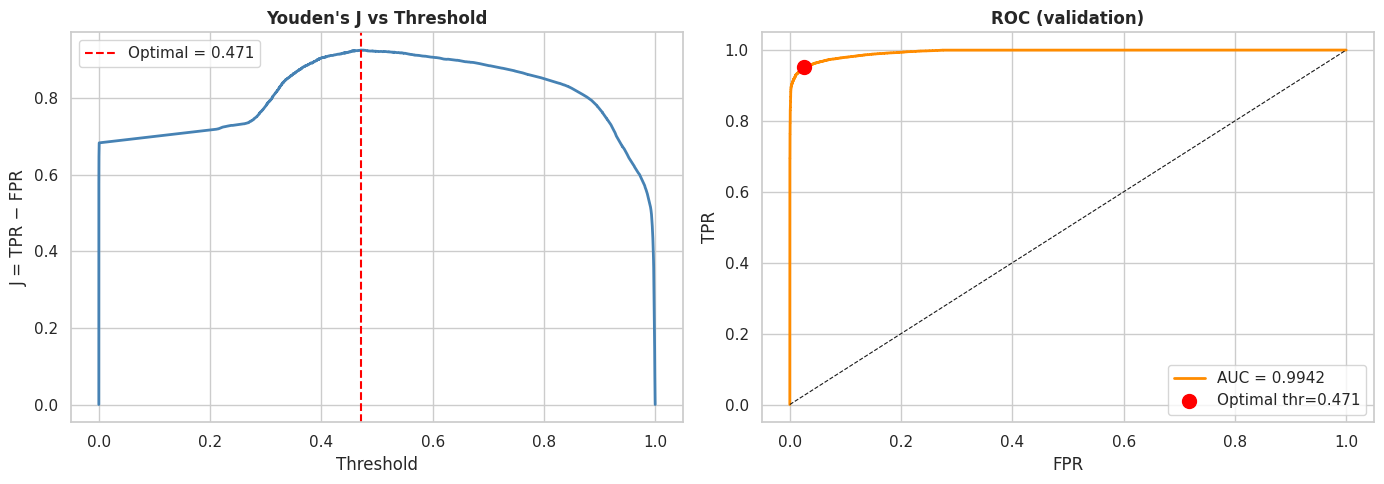

In [16]:
best_fold_idx  = cv_df['f1'].values.argmax()
best_model     = build_model()
best_model.load_state_dict(
    {k: v.to(DEVICE) for k, v in fold_best_states[best_fold_idx].items()}
)

criterion_eval = get_loss_fn(LOSS_CHOICE, y_train_res)
val_res_raw    = evaluate(best_model, val_loader, criterion_eval, threshold=0.5)
val_probs      = val_res_raw['probs']
val_targets    = val_res_raw['targets']

fpr_arr, tpr_arr, thresholds = roc_curve(val_targets, val_probs, pos_label=1)
j_scores      = tpr_arr - fpr_arr
opt_idx       = np.argmax(j_scores)
OPT_THRESHOLD = float(thresholds[opt_idx])

print(f' Optimal threshold (Youden\'s J on val set): {OPT_THRESHOLD:.4f}')
print(f'  TPR at optimal: {tpr_arr[opt_idx]:.4f}')
print(f'  FPR at optimal: {fpr_arr[opt_idx]:.4f}')
print(f'  J score       : {j_scores[opt_idx]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

j_plot = j_scores[:-1] if len(j_scores) > len(thresholds) else j_scores
axes[0].plot(thresholds[:len(j_plot)], j_plot, color='steelblue', lw=2)
axes[0].axvline(OPT_THRESHOLD, color='red', linestyle='--',
                label=f'Optimal = {OPT_THRESHOLD:.3f}')
axes[0].set_title("Youden's J vs Threshold", fontweight='bold')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('J = TPR − FPR')
axes[0].legend()

axes[1].plot(fpr_arr, tpr_arr, color='darkorange', lw=2,
             label=f'AUC = {roc_auc_score(val_targets, val_probs):.4f}')
axes[1].scatter(fpr_arr[opt_idx], tpr_arr[opt_idx],
                color='red', s=100, zorder=5,
                label=f'Optimal thr={OPT_THRESHOLD:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=0.8)
axes[1].set_title('ROC (validation)', fontweight='bold')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend()
plt.tight_layout()
plt.savefig('threshold_selection.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Final Evaluation on Test Set

In [17]:
print(f' Using fold {best_fold_idx+1} (best F1) | Threshold = {OPT_THRESHOLD:.4f}')

test_res = evaluate(best_model, test_loader, criterion_eval, OPT_THRESHOLD)
y_pred   = test_res['preds']
y_true   = test_res['targets']
y_probs  = test_res['probs']

acc      = accuracy_score(y_true, y_pred)
prec     = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
rec      = recall_score(y_true, y_pred,    pos_label=1, zero_division=0)
f1       = f1_score(y_true, y_pred,        pos_label=1, zero_division=0)
roc_auc  = roc_auc_score(y_true, y_probs)
avg_prec = average_precision_score(y_true, y_probs)

cm         = confusion_matrix(y_true, y_pred, labels=[0,1])
tn, fp, fn, tp = cm.ravel()
fpr_test   = fp / (fp + tn + 1e-8)
det_rate   = rec
det_time_ms = (test_res['time_s'] / test_res['n_samples']) * 1000
throughput  = test_res['n_samples'] / test_res['time_s']

print('\n TEST SET RESULTS — CNN Binary (UNSW-NB15)')
print('=' * 48)
print(f'  Accuracy          : {acc:.4f}')
print(f'  Precision (ATTACK): {prec:.4f}')
print(f'  Recall    (ATTACK): {rec:.4f}')
print(f'  F1-Score  (ATTACK): {f1:.4f}')
print(f'  FPR               : {fpr_test:.4f}')
print(f'  Detection Rate    : {det_rate:.4f}')
print(f'  ROC-AUC           : {roc_auc:.4f}')
print(f'  Avg Precision     : {avg_prec:.4f}')
print(f'  Detection time    : {det_time_ms:.4f} ms/sample')
print(f'  Throughput        : {throughput:,.0f} samples/sec')
print(f'\n  TP={tp:,}  FP={fp:,}  TN={tn:,}  FN={fn:,}')
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

 Using fold 2 (best F1) | Threshold = 0.4708

 TEST SET RESULTS — CNN Binary (UNSW-NB15)
  Accuracy          : 0.9562
  Precision (ATTACK): 0.9815
  Recall    (ATTACK): 0.9493
  F1-Score  (ATTACK): 0.9652
  FPR               : 0.0316
  Detection Rate    : 0.9493
  ROC-AUC           : 0.9935
  Avg Precision     : 0.9964
  Detection time    : 0.0122 ms/sample
  Throughput        : 82,168 samples/sec

  TP=31,216  FP=587  TN=17,987  FN=1,666

Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.92      0.97      0.94     18574
      ATTACK       0.98      0.95      0.97     32882

    accuracy                           0.96     51456
   macro avg       0.95      0.96      0.95     51456
weighted avg       0.96      0.96      0.96     51456



## 16. Confusion Matrix

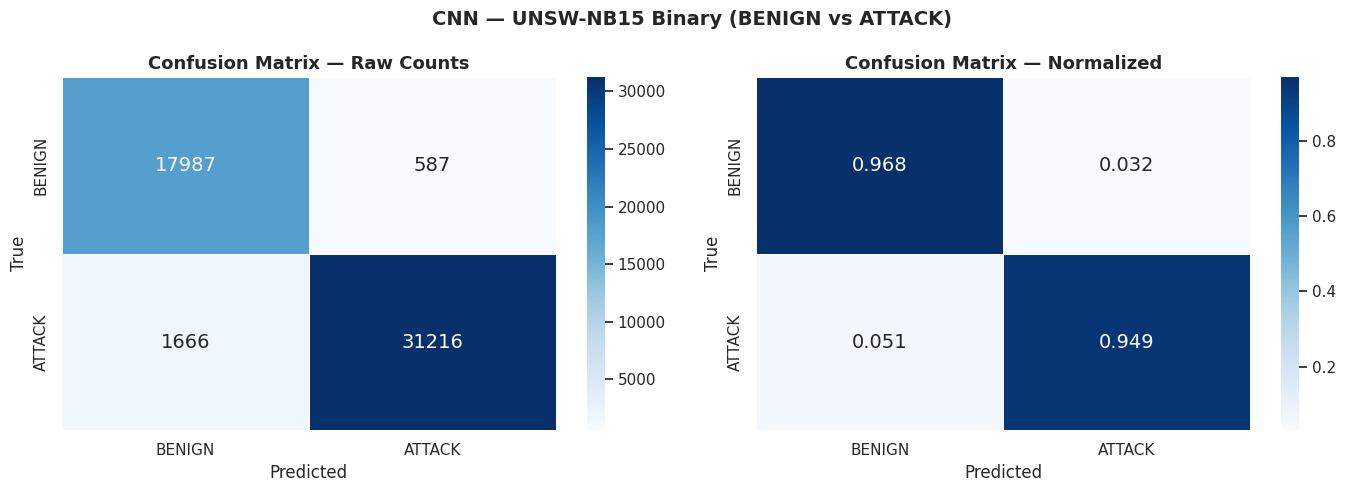

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5, annot_kws={'size': 14})
axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

cm_norm = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-8)
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5, annot_kws={'size': 14})
axes[1].set_title('Confusion Matrix — Normalized', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.suptitle('CNN — UNSW-NB15 Binary (BENIGN vs ATTACK)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_cnn_binary.png', dpi=150, bbox_inches='tight')
plt.show()

## 17. ROC Curve

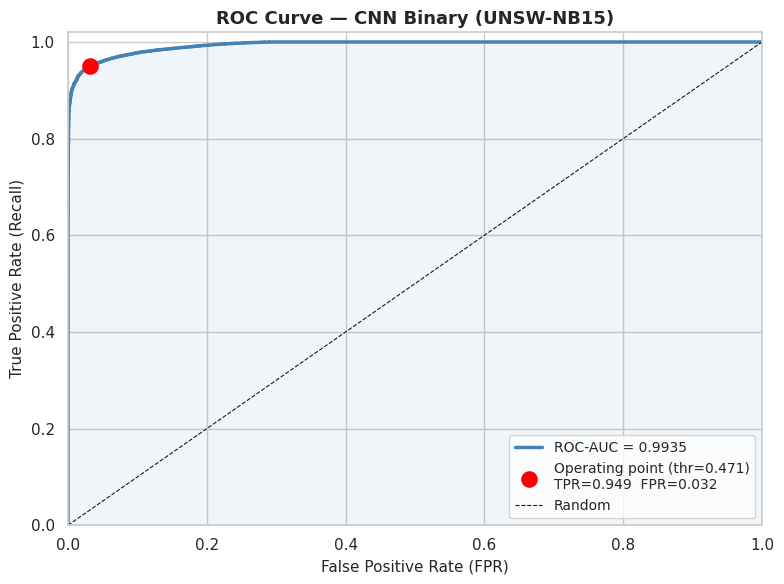

In [19]:
fpr_c, tpr_c, thresh_c = roc_curve(y_true, y_probs, pos_label=1)
roc_auc_final = auc(fpr_c, tpr_c)
opt_test_idx  = np.argmin(np.abs(thresh_c - OPT_THRESHOLD))

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_c, tpr_c, color='steelblue', lw=2.5,
        label=f'ROC-AUC = {roc_auc_final:.4f}')
ax.scatter(fpr_c[opt_test_idx], tpr_c[opt_test_idx],
           color='red', s=120, zorder=5,
           label=f'Operating point (thr={OPT_THRESHOLD:.3f})\n'
                 f'TPR={tpr_c[opt_test_idx]:.3f}  FPR={fpr_c[opt_test_idx]:.3f}')
ax.fill_between(fpr_c, tpr_c, alpha=0.08, color='steelblue')
ax.plot([0,1],[0,1],'k--', lw=0.8, label='Random')
ax.set_title('ROC Curve — CNN Binary (UNSW-NB15)', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate (FPR)', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.legend(fontsize=10)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.savefig('plot_roc_auc.png', dpi=150, bbox_inches='tight')
plt.show()

## 18. Precision-Recall Curve

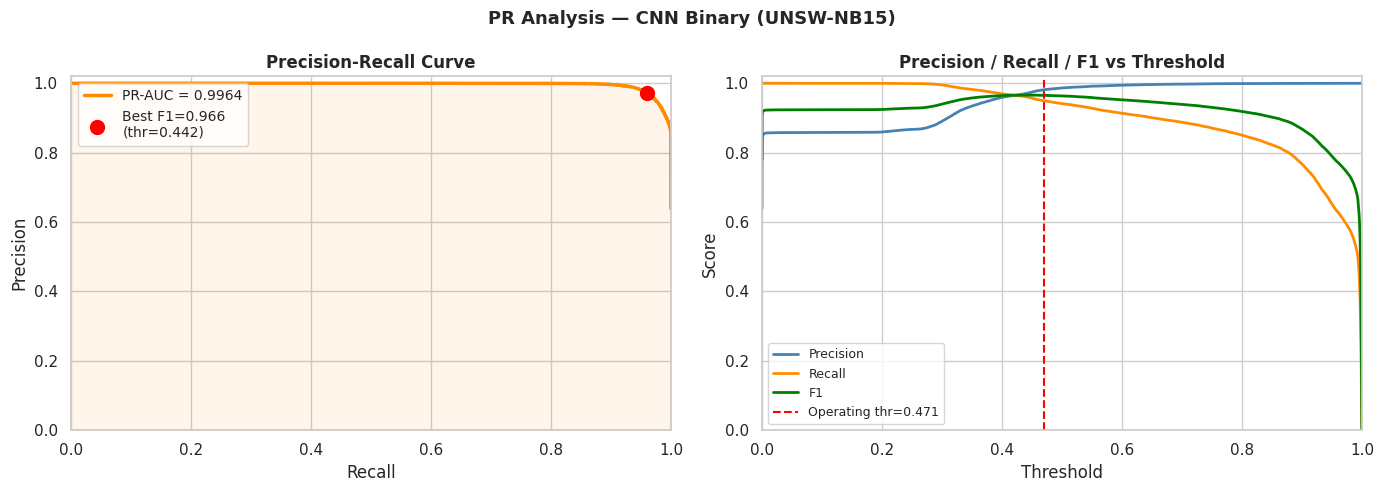

In [20]:
prec_arr, rec_arr, pr_thresholds = precision_recall_curve(y_true, y_probs, pos_label=1)
pr_auc   = auc(rec_arr, prec_arr)
f1_arr   = 2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1] + 1e-8)
best_idx = np.argmax(f1_arr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rec_arr, prec_arr, color='darkorange', lw=2.5,
             label=f'PR-AUC = {pr_auc:.4f}')
axes[0].scatter(rec_arr[best_idx], prec_arr[best_idx],
                color='red', s=100, zorder=5,
                label=f'Best F1={f1_arr[best_idx]:.3f}\n(thr={pr_thresholds[best_idx]:.3f})')
axes[0].fill_between(rec_arr, prec_arr, alpha=0.08, color='darkorange')
axes[0].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].legend(fontsize=10)
axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1.02])

axes[1].plot(pr_thresholds, prec_arr[:-1], color='steelblue',   lw=2, label='Precision')
axes[1].plot(pr_thresholds, rec_arr[:-1],  color='darkorange',  lw=2, label='Recall')
axes[1].plot(pr_thresholds, f1_arr,        color='green',       lw=2, label='F1')
axes[1].axvline(OPT_THRESHOLD, color='red', linestyle='--', lw=1.5,
                label=f'Operating thr={OPT_THRESHOLD:.3f}')
axes[1].set_title('Precision / Recall / F1 vs Threshold', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Score')
axes[1].legend(fontsize=9)
axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.02])

plt.suptitle('PR Analysis — CNN Binary (UNSW-NB15)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 19. Training Curves (CV Folds)

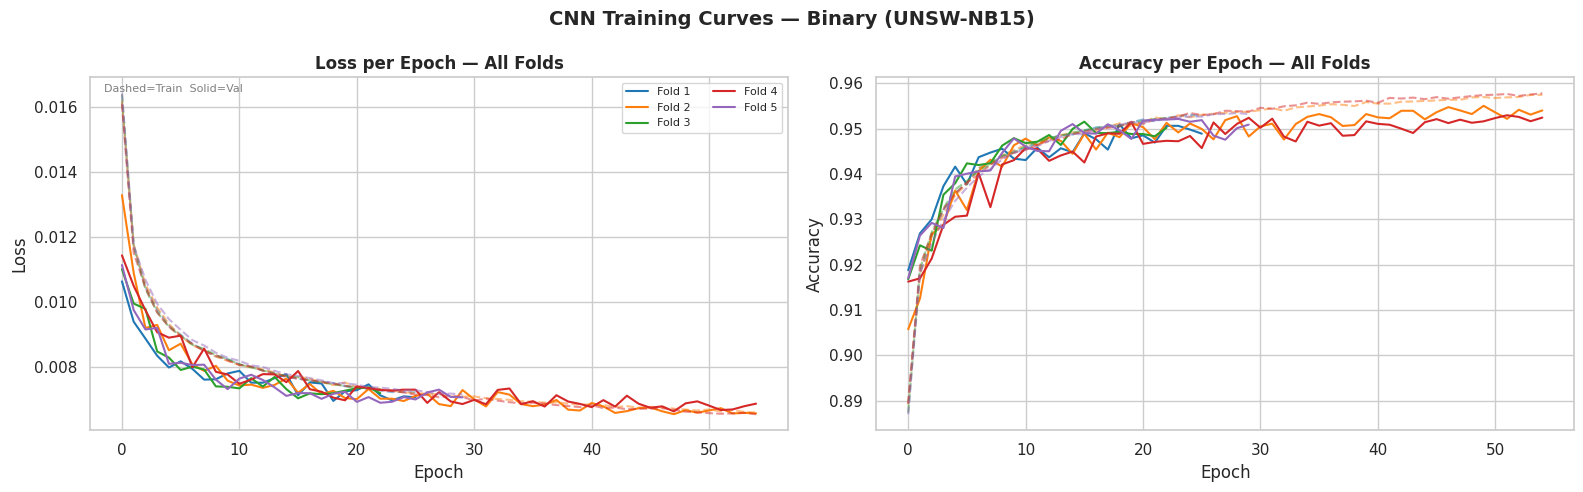

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = plt.cm.tab10.colors

for i, hist in enumerate(cv_histories):
    c = colors[i]
    axes[0].plot(hist['train_loss'], color=c, alpha=0.5, linestyle='--')
    axes[0].plot(hist['val_loss'],   color=c, alpha=1.0, label=f'Fold {i+1}')
    axes[1].plot(hist['train_acc'],  color=c, alpha=0.5, linestyle='--')
    axes[1].plot(hist['val_acc'],    color=c, alpha=1.0)

axes[0].set_title('Loss per Epoch — All Folds', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8, ncol=2)
axes[0].text(0.02, 0.98, 'Dashed=Train  Solid=Val',
             transform=axes[0].transAxes, fontsize=8, va='top', color='gray')
axes[1].set_title('Accuracy per Epoch — All Folds', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')

plt.suptitle('CNN Training Curves — Binary (UNSW-NB15)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 20. Individual Metric Plots (9 plots)

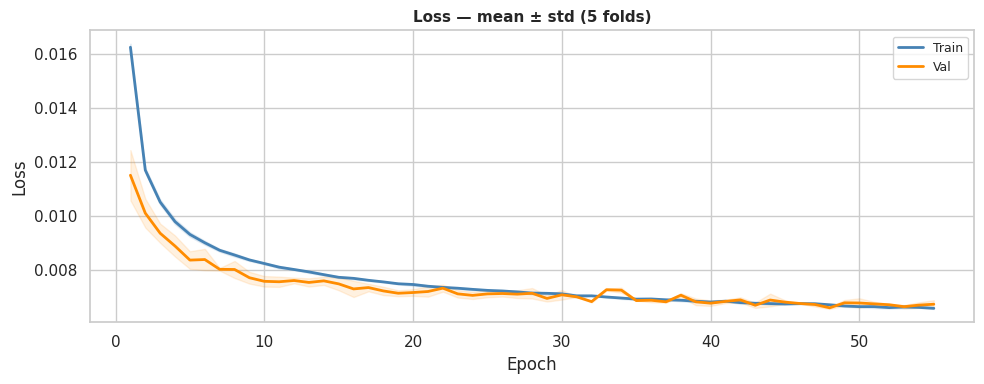

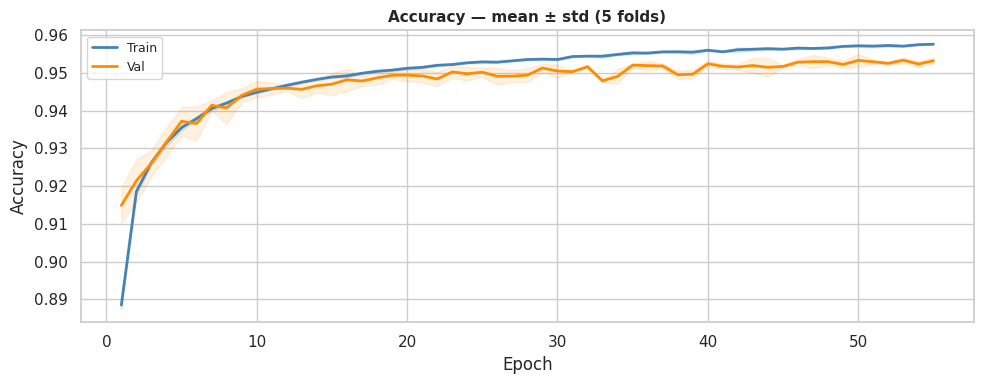

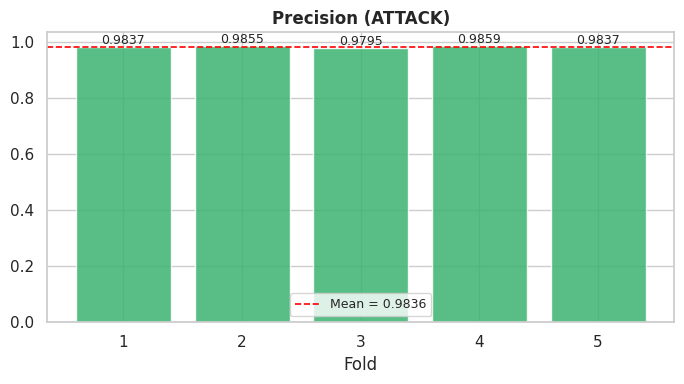

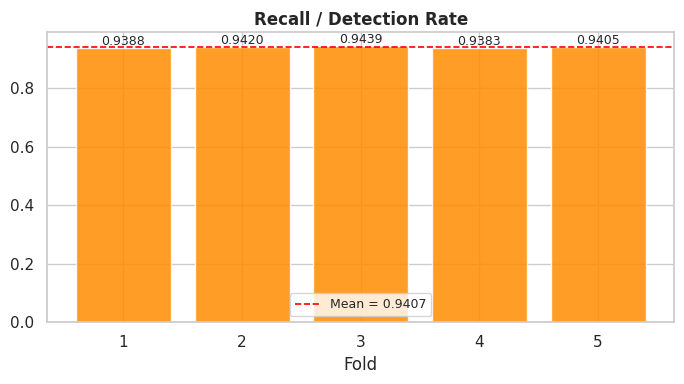

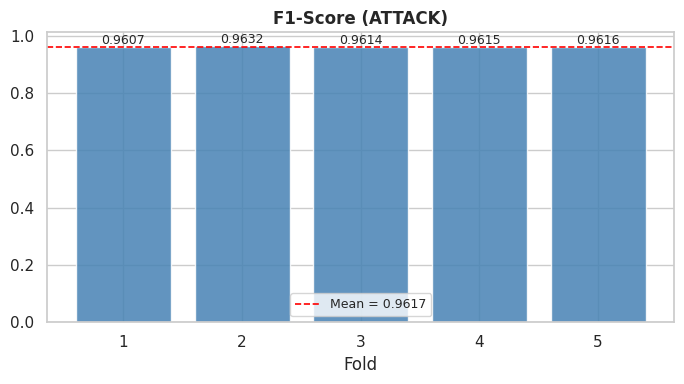

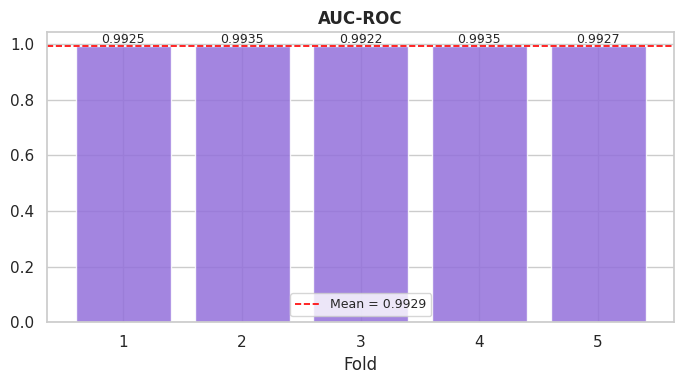

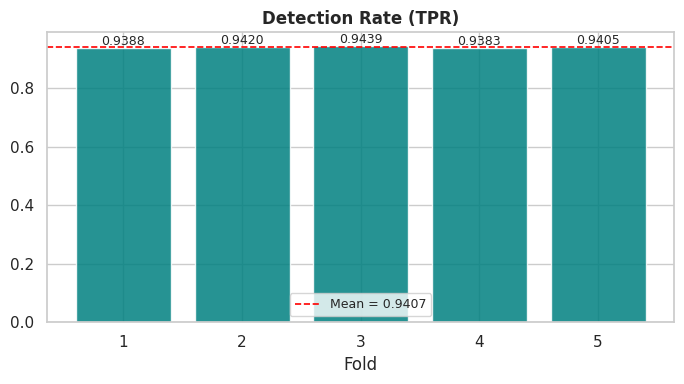

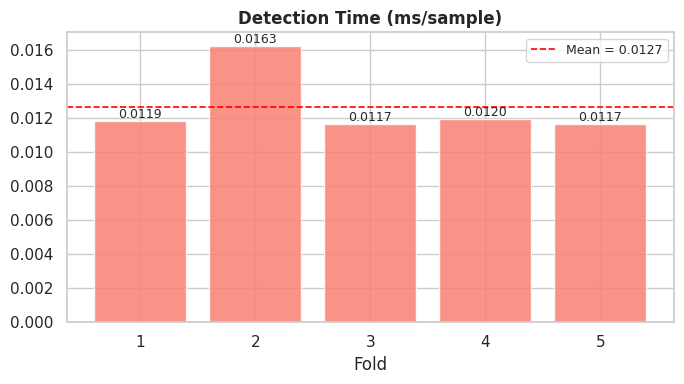

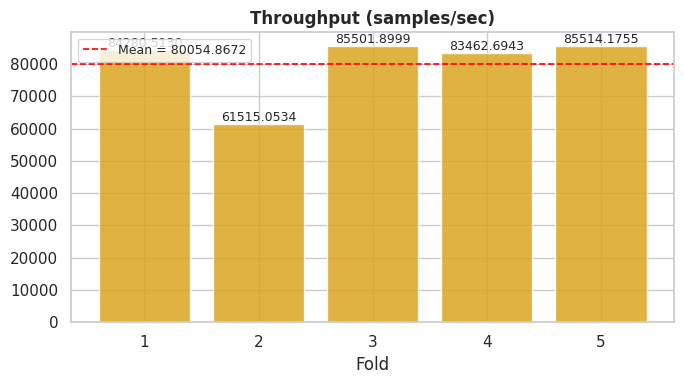

 All 9 individual metric plots saved.


In [22]:
#  Mean ± std training curves
max_ep = max(len(h['train_loss']) for h in cv_histories)

def pad(key):
    arrs = []
    for h in cv_histories:
        a = np.array(h[key])
        if len(a) < max_ep:
            a = np.concatenate([a, np.full(max_ep - len(a), np.nan)])
        arrs.append(a)
    return np.array(arrs)

tr_loss_m = pad('train_loss'); vl_loss_m = pad('val_loss')
tr_acc_m  = pad('train_acc');  vl_acc_m  = pad('val_acc')
ep_x = np.arange(1, max_ep + 1)

def curve_plot(ax, tr, vl, title, ylabel):
    m_tr = np.nanmean(tr, axis=0); s_tr = np.nanstd(tr, axis=0)
    m_vl = np.nanmean(vl, axis=0); s_vl = np.nanstd(vl, axis=0)
    ax.plot(ep_x, m_tr, 'steelblue', lw=2, label='Train')
    ax.fill_between(ep_x, m_tr-s_tr, m_tr+s_tr, alpha=0.12, color='steelblue')
    ax.plot(ep_x, m_vl, 'darkorange', lw=2, label='Val')
    ax.fill_between(ep_x, m_vl-s_vl, m_vl+s_vl, alpha=0.12, color='darkorange')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)

# 1. Loss
fig, ax = plt.subplots(figsize=(10, 4))
curve_plot(ax, tr_loss_m, vl_loss_m, 'Loss — mean ± std (5 folds)', 'Loss')
plt.tight_layout(); plt.savefig('plot_loss.png', dpi=150, bbox_inches='tight'); plt.show()

# 2. Accuracy
fig, ax = plt.subplots(figsize=(10, 4))
curve_plot(ax, tr_acc_m, vl_acc_m, 'Accuracy — mean ± std (5 folds)', 'Accuracy')
plt.tight_layout(); plt.savefig('plot_accuracy.png', dpi=150, bbox_inches='tight'); plt.show()

# 3–9. Per-fold scalar metrics
scalar_plots = [
    ('precision',   'Precision (ATTACK)',         'mediumseagreen'),
    ('recall',      'Recall / Detection Rate',    'darkorange'),
    ('f1',          'F1-Score (ATTACK)',           'steelblue'),
    ('roc_auc',     'AUC-ROC',                    'mediumpurple'),
    ('det_rate',    'Detection Rate (TPR)',        'teal'),
    ('det_time_ms', 'Detection Time (ms/sample)', 'salmon'),
    ('throughput',  'Throughput (samples/sec)',    'goldenrod'),
]

for col, title, color in scalar_plots:
    vals = cv_df[col].values
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(range(1, N_FOLDS+1), vals, color=color, edgecolor='white', alpha=0.85)
    ax.axhline(vals.mean(), color='red', linestyle='--', lw=1.2,
               label=f'Mean = {vals.mean():.4f}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Fold'); ax.set_xticks(range(1, N_FOLDS+1))
    ax.legend(fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'plot_{col}.png', dpi=150, bbox_inches='tight')
    plt.show()

print(' All 9 individual metric plots saved.')

## 21. Per-Fold Summary Bar Chart

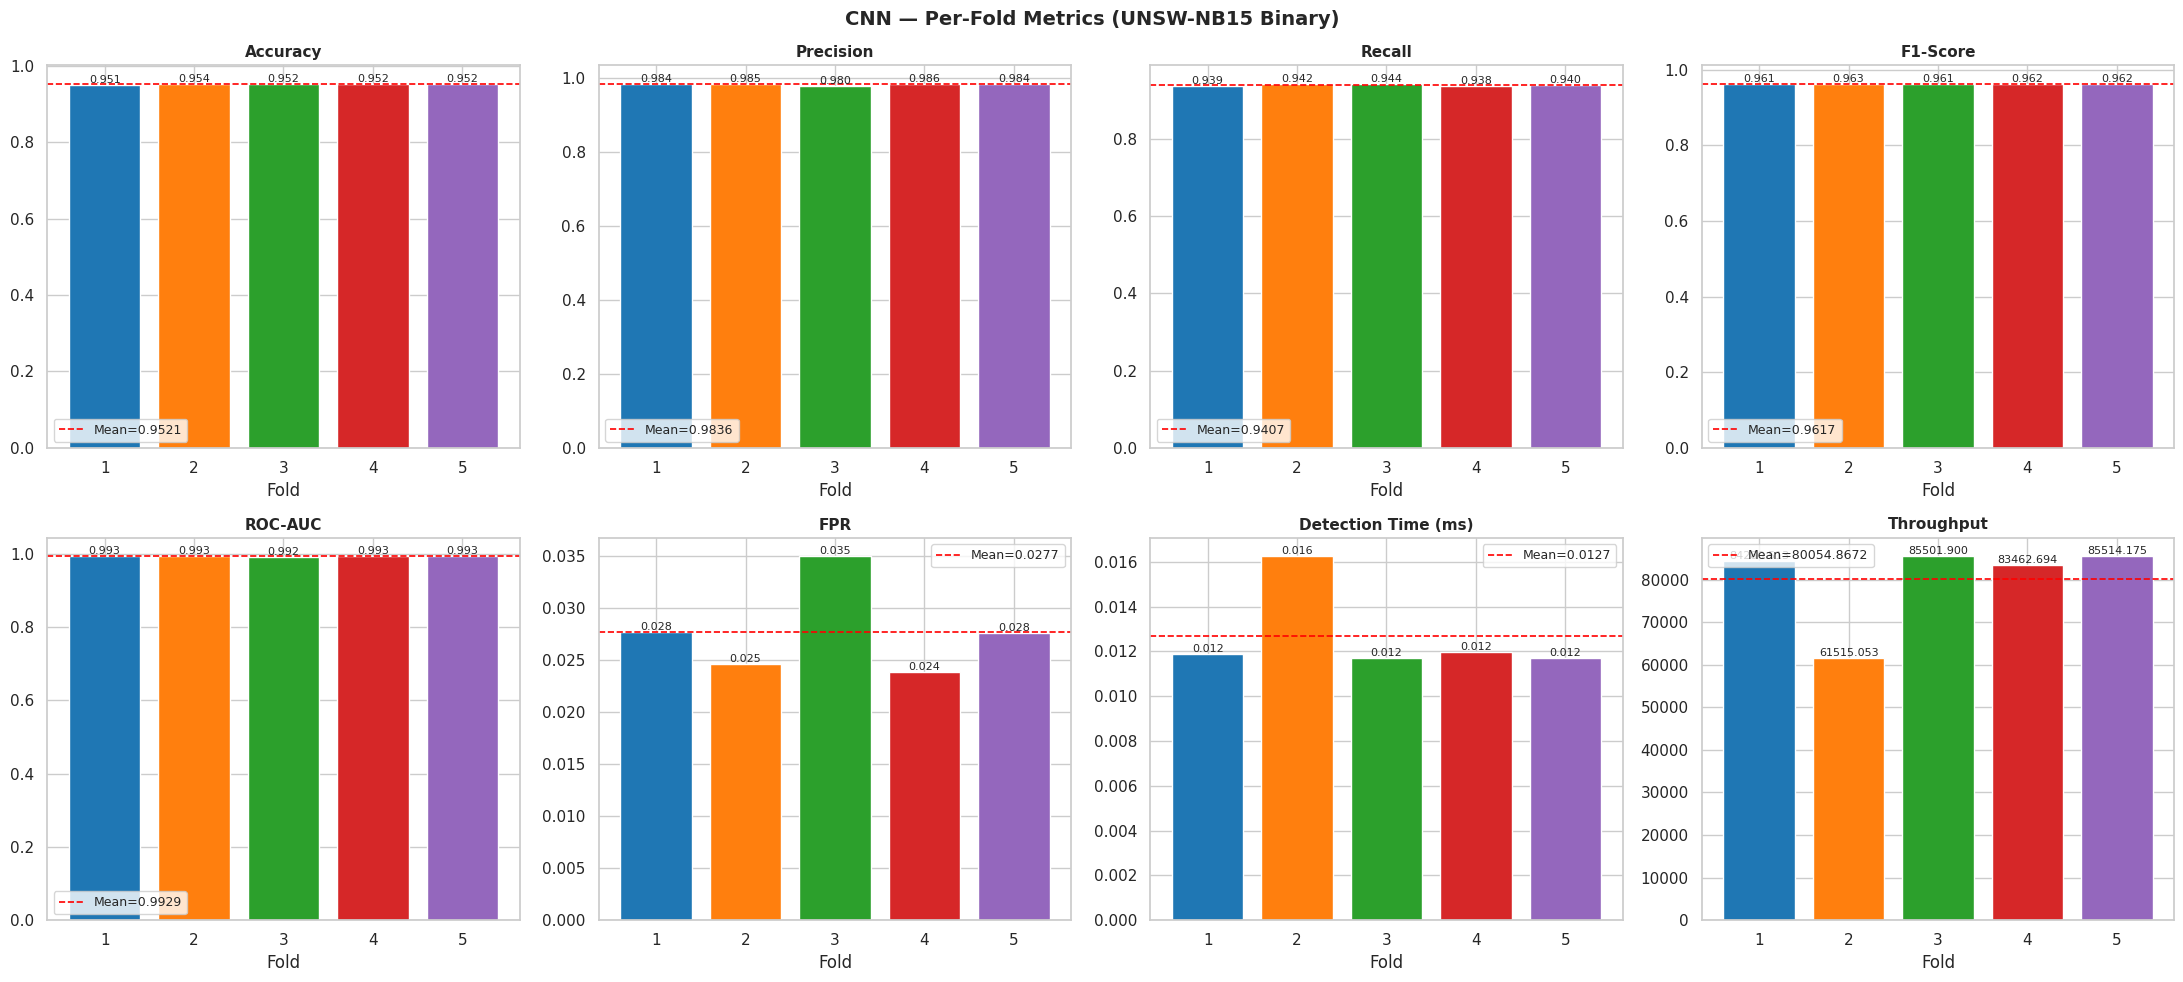

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()
folds = cv_df.index.tolist()

all_metrics = [
    ('acc',         'Accuracy'),
    ('precision',   'Precision'),
    ('recall',      'Recall'),
    ('f1',          'F1-Score'),
    ('roc_auc',     'ROC-AUC'),
    ('fpr',         'FPR'),
    ('det_time_ms', 'Detection Time (ms)'),
    ('throughput',  'Throughput'),
]

for ax, (col, title) in zip(axes, all_metrics):
    vals = cv_df[col].values
    bars = ax.bar(folds, vals, color=plt.cm.tab10.colors[:N_FOLDS], edgecolor='white')
    ax.axhline(vals.mean(), color='red', linestyle='--', lw=1.2,
               label=f'Mean={vals.mean():.4f}')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Fold'); ax.set_xticks(folds)
    ax.legend(fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('CNN — Per-Fold Metrics (UNSW-NB15 Binary)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('per_fold_metrics_cnn_binary.png', dpi=150, bbox_inches='tight')
plt.show()

## 22. Save Best Model

In [24]:
save_path = 'cnn_unsw_nb15_binary_best.pt'
torch.save({
    'model_state_dict': best_model.state_dict(),
    'n_features'      : N_FEATURES,
    'n_classes'       : N_CLASSES,
    'class_names'     : CLASS_NAMES,
    'opt_threshold'   : OPT_THRESHOLD,
    'cnn_blocks'      : CNN_BLOCKS,
    'cnn_dropout'     : CNN_DROPOUT,
    'pool_size'       : POOL_SIZE,
    'fc_layers'       : FC_LAYERS,
    'fc_dropout'      : FC_DROPOUT,
    'best_fold'       : best_fold_idx + 1,
    'cv_results'      : cv_df.to_dict(),
    'test_metrics'    : {
        'acc': acc, 'precision': prec, 'recall': rec, 'f1': f1,
        'fpr': fpr_test, 'roc_auc': roc_auc, 'avg_precision': avg_prec,
        'det_rate': det_rate, 'det_time_ms': det_time_ms, 'throughput': throughput
    }
}, save_path)
print(f' Model saved → {save_path}')
print(f'  Architecture  : CNN1D  blocks={CNN_BLOCKS}')
print(f'  Opt threshold : {OPT_THRESHOLD:.4f}')
print(f'  Best fold     : {best_fold_idx + 1}')


 Model saved → cnn_unsw_nb15_binary_best.pt
  Architecture  : CNN1D  blocks=[(64, 3), (128, 3), (256, 3)]
  Opt threshold : 0.4708
  Best fold     : 2
